## Predict the Success of Startup Businesses    
### Exploratory Data Analysis (EDA)   
### Teresa Ferrill, October 19, 2025  

-----------------------------------------------------------------------------------------------------------------
EDA - Step One: Understand the problem and data content:  
> Problem to solve: What patterns of success are present in successful new startup businesses  
> Data Source: The Kaggle `big_startup_secsees_dataset.csv` dataset will be used to identify patterns of success then classify new startups based on historical data patterns
> Target varible: The model target will be the variable *status*, a categorical variable that reports outcomes such as operating, acquired, failed, and ipo
>> Status of Operating, Acquired, and IPO indicate the business was successful  
>> Status of Closed indicates the business was not successful 

-----------------------------------------------------------------------------------------------------------------
EDA - Step Two: Load and inspect the data:
>Verify data loaded correctly.  
>Identify data types (int, float, object, etc.).  
>Note the number of rows and columns.  
>Identify categorical vs numerical features.  
>List unique values of the target column

In [1]:
# Step two - load and inspect dataset

# Import pandas library
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/big_startup_secsees_dataset.csv")

# Review the dataset
print('View first 5 rows of the dataset\n')
df.head(5)

View first 5 rows of the dataset



,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


In [2]:
# Step two (continued) - Inspect the dataset: describe dataset and identify unique values of target

# Count number of rows
print('\nNumber of data rows, columns, and non-null counts\n')
df.info()

# Describe the dataset, identify number of null entries
print('\nDescribe the dataset')
print(df.describe())

# List unique values of target column
print('\nTarget Column values')
print(df['status'].unique())


Number of data rows, columns, and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   permalink          66368 non-null  object
 1   name               66367 non-null  object
 2   homepage_url       61310 non-null  object
 3   category_list      63220 non-null  object
 4   funding_total_usd  66368 non-null  object
 5   status             66368 non-null  object
 6   country_code       59410 non-null  object
 7   state_code         57821 non-null  object
 8   region             58338 non-null  object
 9   city               58340 non-null  object
 10  funding_rounds     66368 non-null  int64 
 11  founded_at         51147 non-null  object
 12  first_funding_at   66344 non-null  object
 13  last_funding_at    66368 non-null  object
dtypes: int64(1), object(13)
memory usage: 7.1+ MB

Describe the dataset
       funding

-----------------------------------------------------------------------------------------------------------------
EDA - Step Three: Data Cleaning and Preprocessing  
> Identify null values per column  
> Fix data types: convert funding_total_use and funding_rounds from object to numeric  
> Handle missing values for funding_total_use and funding_rounds, change null values to 0  
> Identify and remove duplicate rows    
> Handle outliers with box plots  
> Add categorical columns to support analysis of status column

In [3]:
# Identify null values per column
print('\nNull Values per Column:')
display(df.isnull().sum().sort_values(ascending=False).to_frame('missing_count'))


Null Values per Column:


,missing_count
founded_at,15221
state_code,8547
region,8030
city,8028
country_code,6958
homepage_url,5058
category_list,3148
first_funding_at,24
name,1
permalink,0


In [4]:
# Fix Data Types / Handle Missing Values for funding columns
def to_numeric_safe(s):
    return pd.to_numeric(s, errors='coerce')

# Convert both funding columns to numeric
to_numeric = ['funding_total_usd', 'funding_rounds']

# Convert and fill missing with zero
for col in to_numeric:
    if col in df.columns:
        df[col] = to_numeric_safe(df[col])
        df.fillna({col: 0}, inplace=True)   # <-- sets NaN to 0

# Verify results
print(df[to_numeric].isnull().sum())  # should show 0
display(df[to_numeric].describe(include='all'))

# Verify conversion of object datatype to numeric for identified numeric columns
print('\nView object datatype after Conversion\n')
display(df.info())

funding_total_usd    0
funding_rounds       0
dtype: int64


,funding_total_usd,funding_rounds
count,6.636800e+04,66368.000000
mean,1.491892e+07,1.732522
std,1.690930e+08,1.360251
min,0.000000e+00,1.000000
25%,4.000000e+04,1.000000
50%,1.000000e+06,1.000000
75%,6.800473e+06,2.000000
max,3.007950e+10,19.000000



View object datatype after Conversion

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   permalink          66368 non-null  object 
 1   name               66367 non-null  object 
 2   homepage_url       61310 non-null  object 
 3   category_list      63220 non-null  object 
 4   funding_total_usd  66368 non-null  float64
 5   status             66368 non-null  object 
 6   country_code       59410 non-null  object 
 7   state_code         57821 non-null  object 
 8   region             58338 non-null  object 
 9   city               58340 non-null  object 
 10  funding_rounds     66368 non-null  int64  
 11  founded_at         51147 non-null  object 
 12  first_funding_at   66344 non-null  object 
 13  last_funding_at    66368 non-null  object 
dtypes: float64(1), int64(1), object(12)
memory usage: 7.1+ MB


None

In [5]:
# Identify duplicate rows
print('\nDuplicate Rows:', df.duplicated().sum())


Duplicate Rows: 0


Original shape: (66368, 14)
After cleaning: (66368, 14)


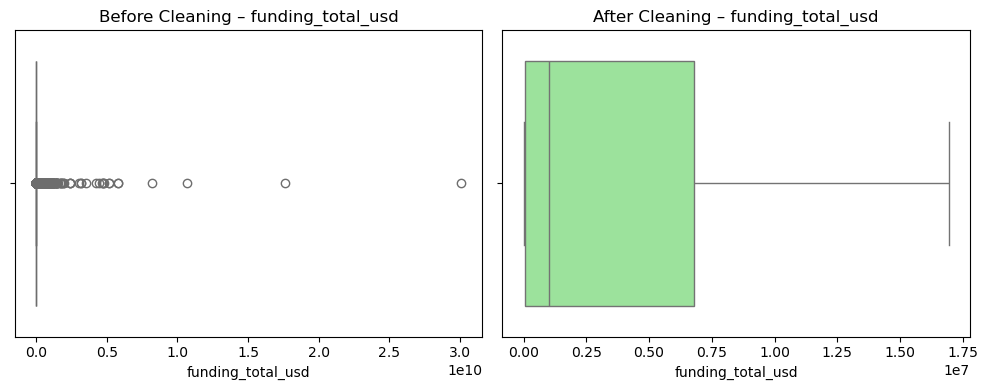

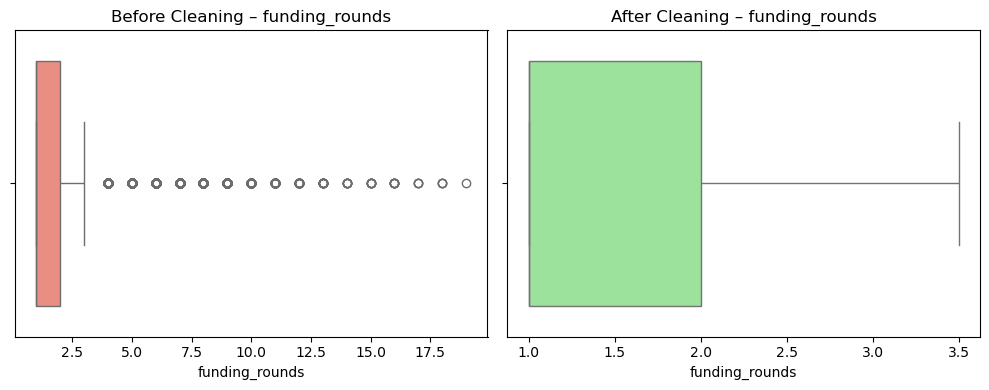

In [6]:
# Handle outliers with boxplots

# Import libraries to support plots
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identify numeric columns 
numeric_cols = df.select_dtypes(include=['number']).columns

# Perform outlier capping using the Interquartile Range (IQR)
# Creates copy of df so the original is not modified directly
def cap_outliers_iqr(dataframe, columns):
    df_capped = dataframe.copy()
    # Loops through each numeric column to process
    for col in columns:
        # Calculates the Interquartile Range (IQR)
        # Q1: 25th percentile (lower quartile)        
        Q1 = df_capped[col].quantile(0.25)
        
        # Q3: 75th percentile (upper quartile)
        Q3 = df_capped[col].quantile(0.75)
        
        # IQR: spread of the middle 50% of data (Q3 - Q1)
        IQR = Q3 - Q1

        # Define the typical range of “non-outlier” data
        # Note - Any value below lower_bound or above upper_bound is considered an outlier
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Instead of deleting outliers, cap them to prevent extreme values from skewing means, variances, or models
        # If a value is below the lower bound, then replace it with the lower bound
        df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
        
        # If a value is above the upper bound, then replace it with the upper bound
        df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])
    return df_capped

# Cap outliers
df_cleaned = cap_outliers_iqr(df, numeric_cols)

# View df shape before and after cap
print(f"Original shape: {df.shape}")
print(f"After cleaning: {df_cleaned.shape}")

# Visual comparison using boxplots 
for col in numeric_cols[:6]:  # limit to first 6 numeric columns for readability
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Before cleaning
    sns.boxplot(x=df[col], ax=axes[0], color='salmon')
    axes[0].set_title(f'Before Cleaning – {col}')
    
    # After cleaning
    sns.boxplot(x=df_cleaned[col], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'After Cleaning – {col}')
    
    plt.tight_layout()
    plt.show()


In [7]:
# Add a success_flag and status_target to capture success or failure based on status column
# Ensure matching case for all values in status column
df['success_flag'] = df['status'].apply(
    lambda x: 'Success' if str(x).lower() in ['operating', 'acquired', 'ipo'] else 'Failure'
)

# Create a numeric “target” version for modeling
df['status_target'] = df['success_flag'].map({'Failure': 0, 'Success': 1}).astype('Int64')

# Show the first 5 rows for quick verification.
display(df[['status','success_flag','status_target']].head(5))

# Count the categories for status and status_target
display(pd.DataFrame(df['status'].value_counts()).reset_index().rename(columns={'index':'status','status':'count'}))
display(pd.DataFrame(df['status_target'].value_counts()).reset_index().rename(columns={'index':'status','status':'count'}))

,status,success_flag,status_target
0,operating,Success,1
1,operating,Success,1
2,operating,Success,1
3,operating,Success,1
4,operating,Success,1


,count,count
0,operating,53034
1,closed,6238
2,acquired,5549
3,ipo,1547


,status_target,count
0,1,60130
1,0,6238


EDA Step 4: Univariate and Bivariate Analysis
> Explore how startup funding is distributed across the dataset  
> Explore how status is distributed across the dataset  
> Determine funding distribution by status target 

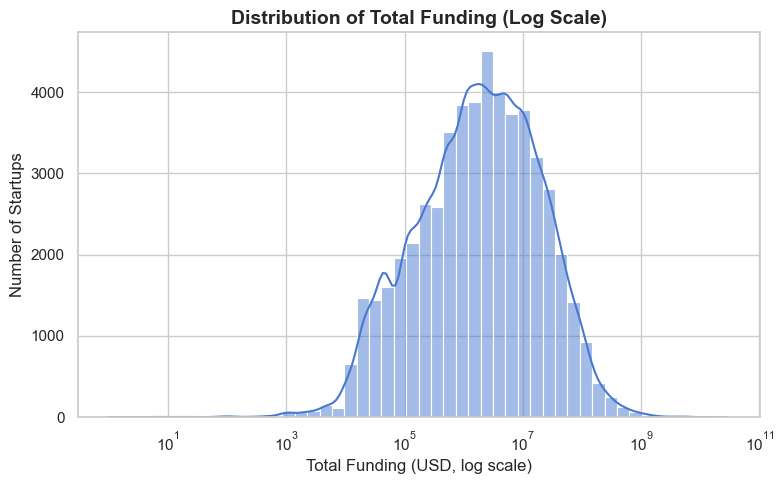

In [8]:
# Distribution of Total Funding 

# Set the Seaborn theme for consistent styling
sns.set(style="whitegrid", palette="muted")

# Filter out those rows that have no startup funding
df_funding = df[df["funding_total_usd"] > 0]

# Create histogram with KDE overlay
plt.figure(figsize=(8, 5))
sns.histplot(df_funding["funding_total_usd"], bins=50, log_scale=True, kde=True)

# Add plot titles and labels
plt.title("Distribution of Total Funding (Log Scale)", fontsize=14, fontweight="bold")
plt.xlabel("Total Funding (USD, log scale)", fontsize=12)
plt.ylabel("Number of Startups", fontsize=12)

# Tight layout ensures labels don't overlap
plt.tight_layout()

# Display the plot
plt.show()


      status  startup_count
0  operating          53034
1     closed           6238
2   acquired           5549
3        ipo           1547


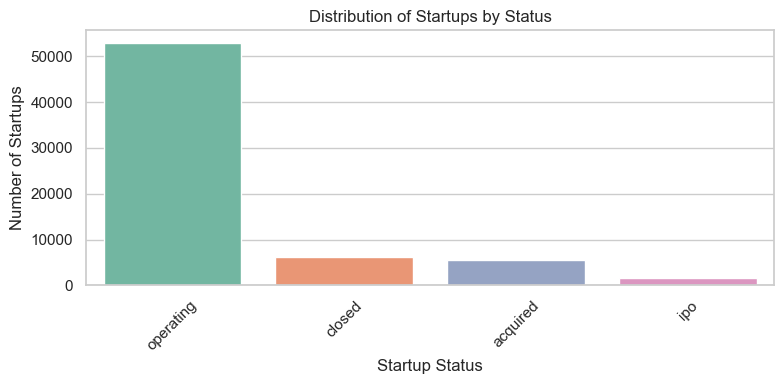

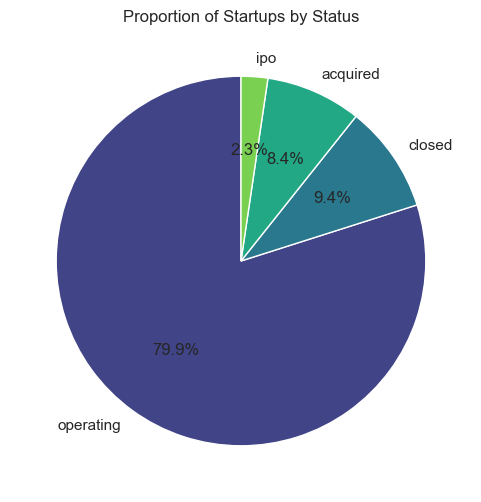

In [9]:
# Distribution of Status

# Count number of startups per status
status_counts = df['status'].value_counts().reset_index()
status_counts.columns = ['status', 'startup_count']

# Print results
print(status_counts)

# Display Bar Plot showing distribution of startups by status
plt.figure(figsize=(8,4))
sns.barplot(
    data=status_counts,
    x='status',
    y='startup_count',
    hue='status',        # <= add hue matching x
    palette='Set2',
    dodge=False
)
plt.title('Distribution of Startups by Status')
plt.xlabel('Startup Status')
plt.ylabel('Number of Startups')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Display Pie Chart showing proportion of startups by status
plt.figure(figsize=(6,6))
plt.pie(status_counts['startup_count'], labels=status_counts['status'], 
        autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(status_counts)))
plt.title('Proportion of Startups by Status')
plt.show()

Bivariate Analysis: funding_total_usd vs. status_target

       funding_total_usd  status_target
count       6.636800e+04        66368.0
mean        1.491892e+07       0.906009
std         1.690930e+08       0.291819
min         0.000000e+00            0.0
25%         4.000000e+04            1.0
50%         1.000000e+06            1.0
75%         6.800473e+06            1.0
max         3.007950e+10            1.0


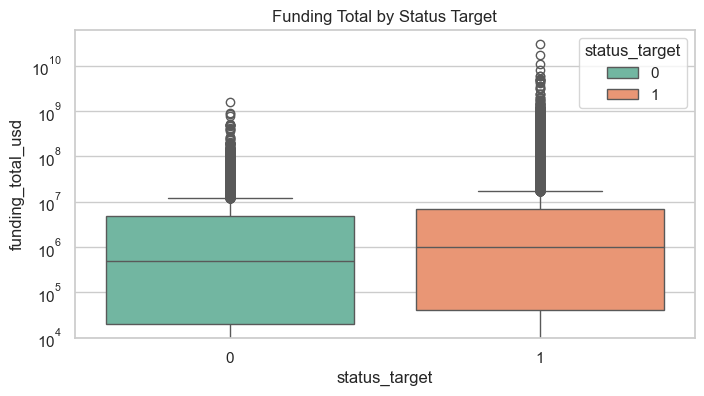


Grouped Summary Statistics by Status Target:


,count,mean,median,std,min,max
status_target,,,,,,
0,6238,8.581389e+06,500000.0,3.912890e+07,0.0,1.567504e+09
1,60130,1.557639e+07,1000000.0,1.771872e+08,0.0,3.007950e+10


In [10]:
# Bivariate Analysis - explore how target_status changes in relation to funding_total_usd

# Import stats from scipy library
from scipy import stats

# Describe funding_total_usd and status_target
print("Bivariate Analysis: funding_total_usd vs. status_target\n")
print(df[["funding_total_usd", "status_target"]].describe(include='all'))

# Boxplot - Funding distribution by Success Target
plt.figure(figsize=(8,4))

sns.boxplot(
    x="status_target",
    y="funding_total_usd",
    hue="status_target",           # ensures multiple colors
    data=df,
    palette="Set2",                # color palette with distinct hues
    dodge=False                    # keeps single boxes per category
)    
plt.title("Funding Total by Status Target")
plt.yscale("log")
plt.show()

# Grouped Summary Statistics
group_stats = df.groupby("status_target")["funding_total_usd"].agg(["count", "mean", "median", "std", "min", "max"])
print("\nGrouped Summary Statistics by Status Target:")
display(group_stats)

-----------------------------------------------------------------------------------------------------------------
EDA - Summary  
> Notes / Findings   
> Initial / Potential Target  
> Next Steps  

**Notes / Findings:**
- A small number of startups attract most of the funding
- Almost 80% of all startups have a status of 'Operating'
- Just over 9% of all startups have a status of 'Closed'

**Initial / Potential Target:**
- Initial Target of `status` - determine is successful or not
- Potential to treat `funding_total_usd` as a regression target

**Next Steps:**
- Drop/engineer features, encode categoricals with memory‑aware strategies (e.g., frequency/target encoding for high‑cardinality columns)
- Train/validate baseline model, model tuning, model interpretation
- Iterate based on error analysis